* Alessio Arcara
* alessio.arcara@studio.unibo.it

In [1]:
import math
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from data.multi_epochs_dataloader import MultiEpochsDataLoader
from data.streethazards import (
    STREET_HAZARDS_CLASSES,
    StreetHazards,
    get_classes_as_dict,
)

# Moduli progetto
from data.transforms import Denormalize, get_data_transforms
from kornia.losses import FocalLoss
from models.model import build_model
from training.losses.contrastive_losses import PrototypicalGlobalLocalTripletLoss, ObjectosphereLoss
from training.metrics import MeanIoU
from training.train import Trainer
from utils.misc import fix_random, generate_run_name, get_device, load_config
from utils.visualize import COLORS, color

# Configurazioni di ambiente
%load_ext autoreload
%autoreload 2

small survey about anomaly segmentation



Premessa: come il mio precedente notebook, link al notebook, sono interessato ad avere delle reti efficienti che mi permettano di poter trainare liberamente e fare diverse prove anche su un dispositivo mac con `mps`.

Guardando i diversi paper che ottenevano alti score nel benchmark SegmentMeIfYouCan, i migliori come mIoU utilizzano Mask classification e di conseguenza Mask2Former con l'aggiunta di un modulo o di tecniche per aggiungere anche il rilevamento di anomalie. Tra tutti ho preferito implementare il paper `Open Semantic Segmentation with Class Similarity` che ottiene un mIoU competitivo, rimanendo al contempo veloce a differenza degli approcci con Mask2Former più lenti di natura, e con un rilevamento di anomalie decisamente migliore. Successivamente, data la recente uscita del paper `Open Panoptic Segmentation`, sempre degli stessi autori, che oltre ad aggiungere la Panoptic Segmentation, risolve alcuni problemi del precedente approccio.

TODO

* Insert anomalies in validation set DONE
* mAP on anomalies
* open mIoU


fa fatica con i solar flare, potrai aggiungere una data augmentation nel training set e poi valutarla nell'ablation

In [2]:
config = load_config("./config.yaml")
fix_random(config["seed"])
device = get_device()

🚀 CUDA device is available!


In [3]:
IMG_H = int(config["training"]["img_height"])
IMG_W = int(config["training"]["img_width"])
TRAIN_ROOT = Path.home() / config["paths"]["train_path"]

data_transforms = get_data_transforms(img_height=IMG_H, img_width=IMG_W)
denorm = Denormalize()

train_data = StreetHazards(
    root_dir=TRAIN_ROOT, subset="training", transforms=data_transforms["train"]
)

val_data = StreetHazards(
    root_dir=TRAIN_ROOT, subset="validation", transforms=data_transforms["val"]
)

num_classes = len(STREET_HAZARDS_CLASSES)
class_dict = get_classes_as_dict()

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of classes: {num_classes}")

Number of training samples: 5125
Number of validation samples: 1031
Number of classes: 14


qui devo far vedere le augmentation

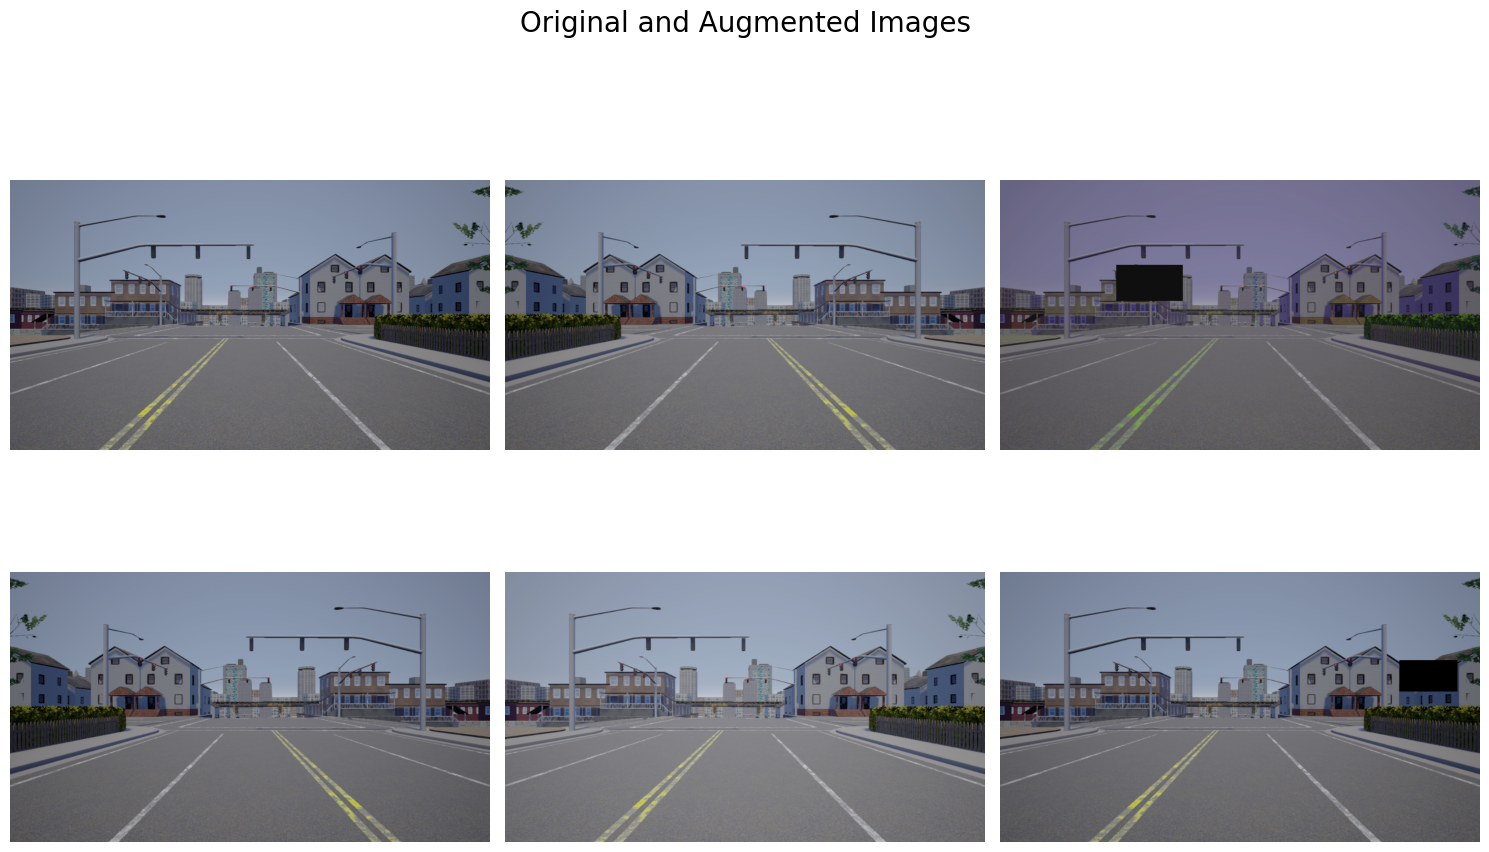

In [4]:
def visualize_augmentations(dataset, num_samples=6, cols=3):
    img, _ = dataset.__getitem__(0, apply_transforms=False)  # original image
    imgs = [img]

    for _ in range(num_samples - 1):
        augmented = data_transforms["train"](image=img)["image"]
        imgs.append(denorm(augmented))

    rows = math.ceil(num_samples / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))

    axes = axes.flatten() if rows > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < num_samples:
            ax.imshow(imgs[i])
            ax.axis("off")
        else:
            ax.set_visible(False)  # Hide unused subplots

    plt.suptitle("Original and Augmented Images", fontsize=20)
    plt.tight_layout()
    plt.show()


visualize_augmentations(train_data, num_samples=6)

In [5]:
NUM_WORKERS = os.cpu_count() - 1
cv2.setNumThreads(0)

train_loader = MultiEpochsDataLoader(
    train_data,
    batch_size=config["training"]["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=3,
)

val_loader = MultiEpochsDataLoader(
    val_data,
    batch_size=config["training"]["batch_size"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 1281
Number of validation batches: 257


In [ ]:
class_weights = train_data.get_class_weights().to(device)
class_weights = class_weights[:-1]
num_classes = num_classes - 1
print(len(class_weights))
print(num_classes)

COMMENTI:

* la wce converge meglio rispetto alla focal loss, ma risulta meno stabile e ogni tanto sul validation diverge decisamente
* best score right now on validation it's 0.55 mIoU,
* attualmente il mio modello fa fatica sulle parti lontane dell'immagine dove il modello non riesce a capire esattamente cosa c'è nell'immagine e sugli oggetti molto piccoli
* il modello non è preciso ai bordi, come affrontare il problema?
* aspp fa qualcosa?



In [ ]:
do_train = False

model, model_info = build_model(config, num_classes)

criterions = [
    (
        1.0,
        PrototypicalGlobalLocalTripletLoss(
            num_classes=num_classes,
            margin_global=1.5,
            margin_local=0.5,
            magnitude=config["training"]["anchors_magnitude"],
        ),
    ),
    (1.0, FocalLoss(alpha=1, gamma=2, reduction="mean")),
]

trainer = Trainer(
    config,
    model,
    device,
    train_loader,
    criterions,
    denorm,
    val_loader,
    class_dict,
    [MeanIoU(num_classes)],
    True,
)

if do_train:
    run_name = generate_run_name(config, model_info, criterions)
    trainer.train(run_name)
else:
    model.load_state_dict(
        torch.load(
            "saved/models/ENC_efficientnet_b2_DEC_2FAM64_ASPP12-24-36_IMG1024x576_LOSS_PrototypicalGlobalLocalTripletLoss,FocalLoss_20250424_055239_epoch50_miou0.7133.pt",
            weights_only=True,
        )
    )

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b2.ra_in1k)
INFO:timm.models._hub:[timm/efficientnet_b2.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


$$
\mathcal{L}(x, y) = \Biggl \lbrace { \max \lbrace 0, \xi - \lVert F(x) \rVert \rbrace^2 \quad \text{if } y \geq 0 \atop \lVert F(x) \rVert_2^2 \hspace{3.7cm} \text{ otherwise } }
$$

In [ ]:
train_data_w_anomalies = StreetHazards(
    root_dir=TRAIN_ROOT,
    subset="training",
    transforms=data_transforms["val"],
    add_anomalies=True,
)

val_data_w_anomalies = StreetHazards(
    root_dir=TRAIN_ROOT,
    subset="validation",
    transforms=data_transforms["val"],
    add_anomalies=True,
)

train_loader_w_anomalies = MultiEpochsDataLoader(
    train_data_w_anomalies,
    batch_size=config["training"]["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

val_loader_w_anomalies = MultiEpochsDataLoader(
    val_data,
    batch_size=config["training"]["batch_size"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
)

<Figure size 1200x800 with 0 Axes>

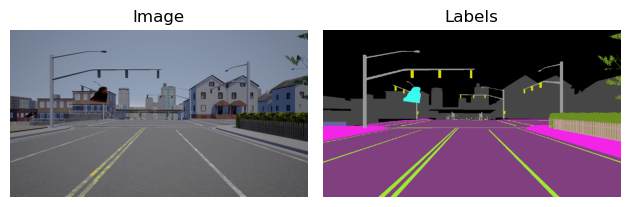

In [ ]:
def visualize_outlier_exposure(sample, figsize=(12, 8)):
    plt.figure(figsize=figsize)
    fig, axs = plt.subplots(1, 2)

    axs[0].imshow(denorm(sample[0]))
    axs[0].set_title("Image")
    axs[0].axis("off")

    axs[1].imshow(color(sample[1], COLORS))
    axs[1].set_title("Labels")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


visualize_outlier_exposure(train_data_w_anomalies[0])

In [ ]:
do_train = True

criterions = [
    (
        0.45,
        PrototypicalGlobalLocalTripletLoss(
            num_classes=num_classes,
            margin_global=1.5,
            margin_local=0.5,
            magnitude=config["training"]["anchors_magnitude"],
        ),
    ),
    (0.45, FocalLoss(alpha=1, gamma=2, reduction="mean", ignore_index=13)),
    (0.10, ObjectosphereLoss(xi=5.0, unknown_label=13)),
]

trainer = Trainer(
    config,
    model,
    device,
    train_loader_w_anomalies,
    criterions,
    denorm,
    val_loader_w_anomalies,
    class_dict,
    [MeanIoU(num_classes)],
    True,
)

if do_train:
    run_name = generate_run_name(config, model_info, criterions)
    trainer.train("OOD_" + run_name)
else:
    model.load_state_dict(
        torch.load(
            "saved/models/ENC_efficientnet_b2_DEC_2FAM64_ASPP12-24-36_IMG1024x576_LOSS_PrototypicalGlobalLocalTripletLoss,FocalLoss_20250424_055239_epoch50_miou0.7133.pt",
            weights_only=True,
        )
    )

wandb: Currently logged in as: alessioarcara (IPCV_ASS2). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 Batches:   0%|          | 0/1281 [00:00<?, ?it/s]

Epoch 2 Batches:   0%|          | 0/1281 [00:00<?, ?it/s]

Evaluating train:   0%|          | 0/1281 [00:00<?, ?it/s]

In [8]:
TEST_ROOT = Path.home() / config["paths"]["test_path"]

test_data = StreetHazards(TEST_ROOT, "test", transforms=data_transforms["val"])

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=2,
    shuffle=False,
    # num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True,
    # prefetch_factor=2
)

In [22]:
import ipywidgets as widgets

anchors = (
    torch.eye(num_classes, device="cuda") * config["training"]["anchors_magnitude"]
)


@torch.no_grad()
def anomaly_map(
    logits: torch.Tensor, anchors: torch.Tensor, threshold: float
) -> torch.Tensor:
    B, C, H, W = logits.shape
    device = logits.device
    anchors = anchors.to(device=device, dtype=logits.dtype)  # [K, C]

    embeds = logits.permute(0, 2, 3, 1).reshape(-1, C)  # [(B·H·W), C]

    # GPU–accelerated pair-wise L2 distances: [(B·H·W), K]
    dists = torch.cdist(embeds, anchors, p=2)

    min_dists, _ = dists.min(dim=1)  # [(B·H·W)]
    anomaly_mask = (min_dists > threshold).reshape(B, H, W)
    return anomaly_mask


def visualize_predictions(model, dataset, device, threshold=0.5):
    model.eval()

    @torch.no_grad()
    def show_prediction(idx, threshold_value):
        """Funzione interna per visualizzare una singola predizione"""
        img, mask = dataset[idx]

        img = img.unsqueeze(0).to(device)

        with torch.inference_mode():
            logits = model(img)
            pred = torch.argmax(logits, dim=1)
            anomaly = anomaly_map(logits, anchors, threshold_value)

        plt.figure(figsize=(15, 10))

        plt.subplot(231)
        plt.imshow(denorm(img))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(232)
        plt.imshow(color(mask.squeeze(), COLORS))
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(233)
        plt.imshow(color(pred.cpu().squeeze(), COLORS))
        plt.title("Predicted")
        plt.axis("off")

        plt.subplot(234)
        plt.imshow(anomaly.cpu().squeeze(), cmap="hot")
        plt.title("Anomaly Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    idx_slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset) - 1, step=1, description="Indice:"
    )

    threshold_slider = widgets.FloatSlider(
        value=threshold, min=0.0, max=50.0, step=0.1, description="Threshold:"
    )

    widgets.interact(show_prediction, idx=idx_slider, threshold_value=threshold_slider)

In [ ]:
visualize_predictions(model, test_data, "cuda")

interactive(children=(IntSlider(value=0, description='Indice:', max=1499), FloatSlider(value=0.5, description=…

## steps per finire il progetto

- secondo validation set injectato con "anomalie"
- calcolo mean average precision

In [ ]:
!pip install pytorch-ood 

5